In [135]:
from comsar import PitchTrack
from apollon.audio import AudioFile
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from apollon.onsets import FluxOnsetDetector
import apollon.segment as aps
import sounddevice as sd

In [2]:
params=aps.SegmentationParams(2205,1985,True)
tt = PitchTrack(params)

In [3]:
a=tt.extract('C:/C/Rolf/COMSAR_alt/audio/rbfr/esra_005_00530.wav')

Pitch ... 156.8 s.
SPL ... 0.5723 s.


In [4]:
snd = AudioFile('C:/C/Rolf/COMSAR_alt/audio/rbfr/esra_005_00530.wav')
ond = FluxOnsetDetector(snd.fps)
ond.detect(snd.data)

39936

In [150]:
dd=4
sd.play(snd.data[ond.onsets.loc[:,'frame'].values[dd]:ond.onsets.loc[:,'frame'].values[dd+1]],44100)

In [137]:
sd.stop()

In [5]:
dcent=1
noctave=8
f0=27.5
tonalsystem = tt.extract_global(a.data, dcent, noctave, f0)

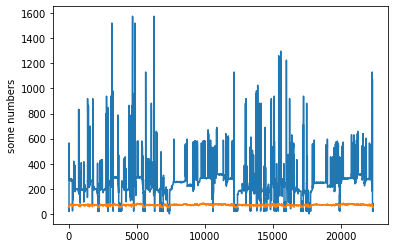

In [81]:
plt.plot(a.data)
plt.ylabel('some numbers')
plt.show()

In [119]:
dcent=1
f0=27.5
noctaves=8
n=int(1200/dcent*noctaves)
no=int(1200/dcent)
nnotes=ond.onsets.loc[:,'frame'].values.size
notes= np.zeros(nnotes)

root=np.power(2,1/(1200/dcent))
root1200=1/np.log(root)
#maxf: strongest frequency between two onsets
maxf=np.zeros(nnotes)
#ts: cent values of tonal system chosen (chosen either from soundfile or freely)
ts=tonalsystem[4][1]
#tslen: number of notes in the tonal system
tslen=np.where(ts == 0)[0][1]
#ff: fundamental frequency of recording (strongest frequency)
ff=tonalsystem[2]
#ff0: lowest pitch around 20 Hz as a sub-octave below ff
ff0=np.power(2,np.round(np.log(ff/20)/np.log(2)))
#tsfreq: Frequencies of the tonal system chosen over noctaves with respect to fundamental ff
tsfreq = np.zeros(tslen * noctaves)

#pitch information
if a.data.ndim == 1:
    data = a.data
else:
    data = a.data[:,0]

for i in range(0,noctave):
    for j in range(0,tslen):
        tsfreq[i*tslen+j] = ff0 * np.power(1.000577790,1200*i+ts[j])

fmax=max(tsfreq)
for j in range(0,nnotes-1):
    c=np.zeros(int(fmax))
    
    for i in range(int(ond.onsets.loc[:,'frame'].values[j]/2205),int(ond.onsets.loc[:,'frame'].values[j+1]/2205)):
        sl = np.round(np.log(data[i]/f0) * root1200 / dcent)
        if data[i] <= fmax and data[i] > ff0:
            c[int(data[i])] += 1
    maxa = max(c)
    maxf[j] = np.where(c == maxa)[0][0]
            #maxf[j] = f0 * np.power(1.000577790, maxs)
    

In [120]:
maxf

array([270., 270., 270., 267., 268., 262., 262., 253., 246., 256., 223.,
       222., 221., 221., 200., 180., 177., 182., 186., 193., 195., 196.,
       197., 198., 196., 195., 816., 172., 268., 230., 220., 408., 189.,
       193., 193., 191., 187., 187., 192., 191., 193., 195., 195., 186.,
       416., 174., 175., 174., 174., 180., 177., 195., 265., 223., 222.,
       215., 213., 214., 213., 214., 219., 218., 218., 246., 700., 265.,
       265., 262., 223., 221., 220., 218., 215., 213., 420., 196., 195.,
       198., 196., 196., 196., 196., 197., 198., 197., 195., 196., 196.,
       195., 192., 183., 175., 175., 175., 172., 166., 163., 142.,  22.,
        23.,  56.,  22.,  20.,   0.])

In [160]:
ff0=np.power(2,np.round(np.log(ff/20)/np.log(2)))
tsfreq = np.zeros(tslen * noctaves)
for i in range(0,noctave):
    for j in range(0,tslen):
        tsfreq[i*tslen+j] = ff0 * np.power(1.000577790,1200*i+ts[j])

In [122]:
fps=44100
#Frequency of the note in the tonal system
notefreq = np.zeros(nnotes)
#Deviation of the real pitch from the theoretical tonal system pitch in cent
notedevcent = np.zeros(nnotes)
#Length of notes in ms
notelen = np.zeros(nnotes)
#MIDI note in Just Intonation
notemidi = np.zeros(nnotes)
#Deviation from MIDI note in Just Intonation in cent
notemididev = np.zeros(nnotes)

for j in range(0,nnotes-1):
    #Cummulating frequencies between two onsets in variable c
    c=np.zeros(int(fmax))
    for i in range(int(ond.onsets.loc[:,'frame'].values[j]/2205),int(ond.onsets.loc[:,'frame'].values[j+1]/2205)): 
        if data[i] <= fmax and data[i] > ff0:
            c[int(data[i])]+= 1
            
    notelen[j] = int(ond.onsets.loc[:,'frame'].values[j+1]/fps*1000)-int(ond.onsets.loc[:,'frame'].values[j]/fps*1000)
    
    #Strongest frequency is compared to all frequencies in tonal system and nearest is chosen as note for this onset
    maxa = max(c)
    maxf = np.where(c == maxa)[0][0]
    diff=np.zeros(tslen*noctaves)
    for i in range (0,tslen*noctaves):
        diff[i] = abs(maxf-tsfreq[i])
        
    notefreq[j] = tsfreq[int(np.where(diff == min(diff))[0][0])]
    notedevcent[j] = maxf - notefreq[j]
    notemidi[j] = np.round(np.log(maxf/f0)/np.log(1.05946))
    notemididev[j] = np.round(np.log(maxf/f0)/np.log(1.000577790) - notemidi[j]*100)
    
        

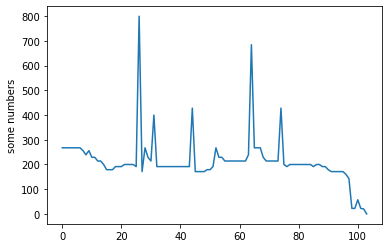

In [131]:
plt.plot(notefreq)
plt.ylabel('some numbers')
plt.show()

In [133]:
notemidi

array([40., 40., 40., 39., 39., 39., 39., 38., 38., 39., 36., 36., 36.,
       36., 34., 33., 32., 33., 33., 34., 34., 34., 34., 34., 34., 34.,
       59., 32., 39., 37., 36., 47., 33., 34., 34., 34., 33., 33., 34.,
       34., 34., 34., 34., 33., 47., 32., 32., 32., 32., 33., 32., 34.,
       39., 36., 36., 36., 35., 36., 35., 36., 36., 36., 36., 38., 56.,
       39., 39., 39., 36., 36., 36., 36., 36., 35., 47., 34., 34., 34.,
       34., 34., 34., 34., 34., 34., 34., 34., 34., 34., 34., 34., 33.,
       32., 32., 32., 32., 31., 31., 28., -4., -3., 12., -4., -6.,  0.])

In [124]:
diff=np.zeros(tslen*noctaves)
for i in range (0,tslen*noctaves):
    diff[i] = abs(maxf[0]-tsfreq[i])

IndexError: invalid index to scalar variable.

In [167]:
diff

array([ 180.        ,  178.33893887,  174.4691451 ,  172.22015915,
        169.75142357,  163.99998106,  163.99998106,  160.67785684,
        152.93826471,  148.44029015,  143.50281607,  131.99992425,
        131.99992425,  125.35567188,  109.87647846,  100.88052401,
         91.00557001,   67.99977275,   67.99977275,   54.71126015,
         23.75285498,    5.76093543,   13.98898425,   60.000606  ,
         60.000606  ,   86.57764693,  148.49449391,  184.4783543 ,
        223.97821704,  316.00151499,  316.00151499,  369.15562831,
        492.98939555,  564.95715894,  643.95693115,  828.00363598,
        828.00363598,  934.31192554, 1181.97960658, 1325.91521853,
       1483.91485647, 1852.00848395, 1852.00848395, 2064.62518889,
       2559.96084412, 2847.83223837, 3163.83170126, 3900.01939189])

In [168]:
np.where(diff == min(diff))[0][0]

21

In [163]:
tsfreq

array([  16.        ,   17.66106113,   21.5308549 ,   23.77984085,
         26.24857643,   32.00001894,   32.00001894,   35.32214316,
         43.06173529,   47.55970985,   52.49718393,   64.00007575,
         64.00007575,   70.64432812,   86.12352154,   95.11947599,
        104.99442999,  128.00022725,  128.00022725,  141.28873985,
        172.24714502,  190.23906457,  209.98898425,  256.000606  ,
        256.000606  ,  282.57764693,  344.49449391,  380.4783543 ,
        419.97821704,  512.00151499,  512.00151499,  565.15562831,
        688.98939555,  760.95715894,  839.95693115, 1024.00363598,
       1024.00363598, 1130.31192554, 1377.97960658, 1521.91521853,
       1679.91485647, 2048.00848395, 2048.00848395, 2260.62518889,
       2755.96084412, 3043.83223837, 3359.83170126, 4096.01939189])

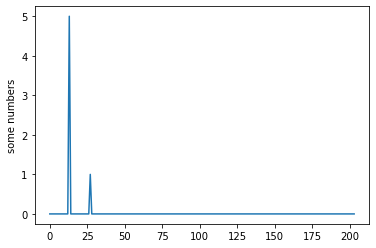

In [124]:
plt.plot(c)
plt.ylabel('some numbers')
plt.show()

In [126]:
27*20

540

In [88]:
np.power(2,8)

256